# Delivery-Time Prediction

This notebook **loads the trained model from `model/`** and uses it to:
1. predict delivery times for the test set (reproducing our **2.741** submission),
2. score a brand-new order,
3. run **what-if analysis** (how does predicted delivery change as the seller moves farther away?),
4. show **what drives the predictions** (feature importance).

See `approach.md` (plain-English) and `technical.md` (engineering detail) for the full method.
Run the cells top-to-bottom.

## 1. Setup

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from pipeline import prepare   # our feature pipeline (fit on train, applied to any query)

pd.set_option("display.width", 160)
print("libraries loaded")

libraries loaded


## 2. Load the data

In [ ]:
train = pd.read_csv("data/train.csv")
test  = pd.read_csv("data/test.csv")
print("train:", train.shape, " test:", test.shape)
display(train[["customer_city","seller_city","price","freight_value",
               "product_category_name_english","delivery_time_days"]].head())
train["delivery_time_days"].describe(percentiles=[.25,.5,.75,.95]).round(2)

train: (85159, 26)  test: (15029, 25)


,customer_city,seller_city,price,freight_value,product_category_name_english,delivery_time_days
0,sao joaquim da barra,curitiba,44.99,2.83,health_beauty,54.81
1,sao paulo,ribeirao preto,32.49,11.74,consoles_games,20.30
2,ipatinga,ibitinga,74.90,17.37,furniture_decor,28.68
3,hortolandia,ibitinga,119.90,13.56,furniture_decor,27.54
4,taubate,limeira,29.99,10.96,fashion_shoes,10.73


count    85159.00
mean        13.23
std          9.90
min          0.53
25%          7.11
50%         11.00
75%         16.52
95%         30.59
max        209.63
Name: delivery_time_days, dtype: float64

## 3. How the model works

- **Target:** `delivery_time_days`. Metric: **MAE** (avg error in days, lower = better). The
  MAE-optimal prediction is the **median**, so our models use L1 / log1p objectives.
- **Features (67):** haversine distance, freight ratios, time/seasonality, and **out-of-fold target
  encodings** of seller / city / category / region (historical average delivery, leak-free).
- **Model:** a weighted blend of 4 gradient-boosted models (3× LightGBM, 1× XGBoost), saved in
  `model/`.

## 4. Build the features for the test set

`prepare(train, query)` fits all encoders on `train` and applies them to `query` — identical to how the model was trained.

In [ ]:
X_train, y, X_test, feat_cols, _ = prepare(train, test)
print(f"{len(feat_cols)} features built for {len(X_test)} test orders")
X_test[feat_cols[:8]].head()

67 features built for 15029 test orders


,quantity,price,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm,volume_cm3
0,1.0,40.000000,4.570000,283.0,20.0,10.0,16.0,3200.0
1,1.0,28.900000,9.510000,650.0,22.0,12.0,22.0,5808.0
2,1.0,17.900000,18.230000,250.0,40.0,4.0,30.0,4800.0
3,1.0,12.900000,7.390000,150.0,25.0,7.0,16.0,2800.0
4,1.0,99.900002,18.799999,314.0,18.0,11.0,14.0,2772.0


## 5. Load the saved model

In [ ]:
def load_saved_model(model_dir="model"):
    meta = json.load(open(f"{model_dir}/meta.json"))
    boosters = []
    for m in meta["models"]:
        if m["framework"] == "lgb":
            b = lgb.Booster(model_file=m["path"])
        else:
            b = xgb.Booster(); b.load_model(m["path"])
        boosters.append((m, b))
    return meta, boosters

meta, boosters = load_saved_model()
pd.DataFrame([{ "model": m["name"], "framework": m["framework"],
               "log_target": m["log_target"], "weight": m["weight"], "rounds": m["rounds"]}
             for m in meta["models"]])

,model,framework,log_target,weight,rounds
0,lgb_l1_log,lgb,True,0.474,1791
1,lgb_l1_deep,lgb,False,0.335,641
2,lgb_l2_log,lgb,True,0.106,257
3,xgb_mae,xgb,False,0.085,438


## 6. Predict — the blend function

Each booster predicts, we undo the log where used, clip to a sane range, and combine with the saved weights.

In [ ]:
def predict_orders(query_df, train_df, meta, boosters):
    """query_df must have the same columns as data/test.csv."""
    _, _, Xq, _, _ = prepare(train_df, query_df)
    Xq = Xq[meta["feat_cols"]]
    lo, hi = meta["clip"]
    blend, wsum = np.zeros(len(Xq)), 0.0
    for m, b in boosters:
        p = b.predict(Xq) if m["framework"] == "lgb" else b.predict(xgb.DMatrix(Xq))
        if m["log_target"]:
            p = np.expm1(p)
        p = np.clip(p, lo, hi)
        blend += m["weight"] * p
        wsum  += m["weight"]
    return np.clip(blend / wsum, lo, hi)

pred_test = predict_orders(test, train, meta, boosters)
submission = pd.DataFrame({"id": np.arange(len(pred_test)),
                           "delivery_time_days": np.round(pred_test, 2)})
submission.to_csv("notebook_submission.csv", index=False)
print("wrote notebook_submission.csv")
submission.head()

wrote notebook_submission.csv


,id,delivery_time_days
0,0,13.13
1,1,3.52
2,2,10.66
3,3,3.27
4,4,8.52


### Sanity check vs the locked 2.741 submission

In [ ]:
locked = pd.read_csv("submission.csv")["delivery_time_days"].values
corr = np.corrcoef(pred_test, locked)[0, 1]
print(f"correlation with locked submission: {corr:.4f}")
print(f"mean abs difference: {np.abs(pred_test - locked).mean():.3f} days")
print(f"predicted days  -> median {np.median(pred_test):.2f}  mean {pred_test.mean():.2f}")

correlation with locked submission: 0.9961
mean abs difference: 0.254 days
predicted days  -> median 7.67  mean 8.16


## 7. Distribution of predictions

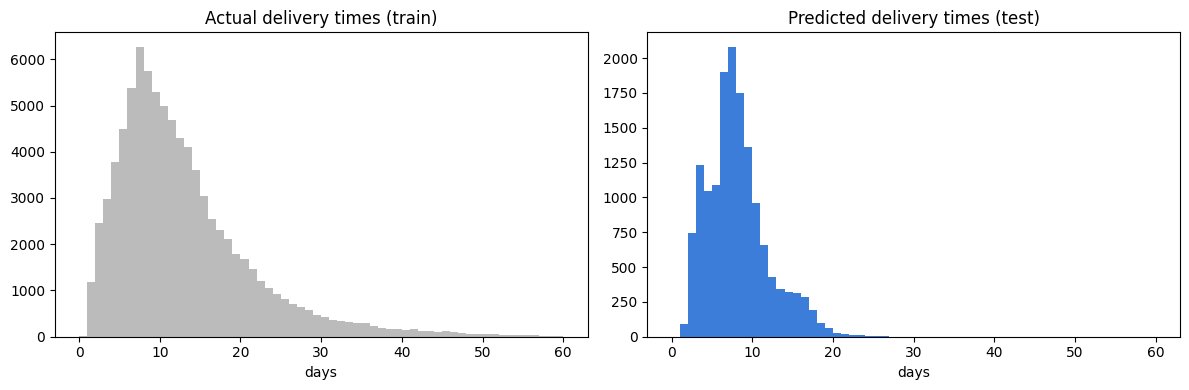

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train["delivery_time_days"], bins=60, range=(0, 60), color="#bbb")
ax[0].set_title("Actual delivery times (train)"); ax[0].set_xlabel("days")
ax[1].hist(pred_test, bins=60, range=(0, 60), color="#3b7dd8")
ax[1].set_title("Predicted delivery times (test)"); ax[1].set_xlabel("days")
plt.tight_layout(); plt.show()

## 8. Predict a single new order

We take one real test order and score it. To predict a genuinely new order, just fill the same
columns (everything known at checkout time).

In [ ]:
one = test.iloc[[0]].copy()
days = predict_orders(one, train, meta, boosters)[0]
print(f"From seller in {one['seller_city'].values[0]} to customer in "
      f"{one['customer_city'].values[0]}")
print(f"price={one['price'].values[0]}  freight={one['freight_value'].values[0]}  "
      f"weight={one['product_weight_g'].values[0]}g")
print(f"\n  -> predicted delivery: {days:.1f} days")

From seller in araguari to customer in santo antonio de jesus
price=40.0  freight=4.57  weight=283.0g

  -> predicted delivery: 13.6 days


## 9. What-if analysis (for the business stage)

Hold an order fixed but **move the seller progressively farther** from the customer, and watch the
predicted delivery time respond. This is the kind of lever the business strategy can act on
(e.g. regional warehouses).

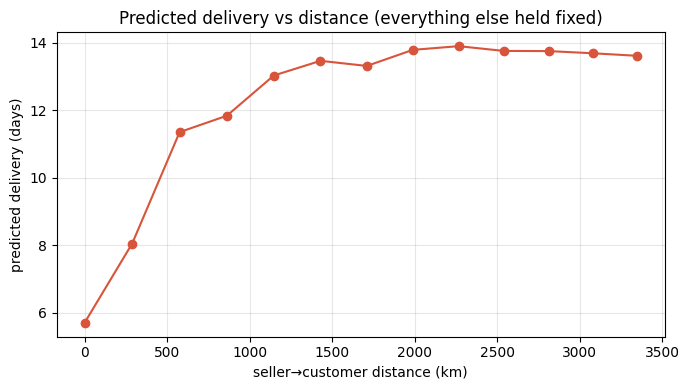

,distance_km,predicted_days
0,0.0,5.7
1,289.0,8.0
2,576.0,11.3
3,862.0,11.8
4,1147.0,13.0
5,1429.0,13.5
6,1710.0,13.3
7,1989.0,13.8
8,2266.0,13.9
9,2540.0,13.8


In [ ]:
from build_features import haversine

base = test.iloc[[0]].copy()
cust_lat, cust_lng = base["customer_lat"].values[0], base["customer_lng"].values[0]
sell_lat0, sell_lng0 = base["seller_lat"].values[0], base["seller_lng"].values[0]

# create variants: shift seller longitude away from the customer in steps
rows, dists = [], []
for f in np.linspace(0, 3.0, 13):          # 0 .. 3x the original offset
    r = base.copy()
    r["seller_lat"] = cust_lat + (sell_lat0 - cust_lat) * f
    r["seller_lng"] = cust_lng + (sell_lng0 - cust_lng) * f
    rows.append(r)
    dists.append(haversine(cust_lat, cust_lng, r["seller_lat"].values[0], r["seller_lng"].values[0]))
variants = pd.concat(rows, ignore_index=True)
pred_var = predict_orders(variants, train, meta, boosters)

plt.figure(figsize=(7, 4))
plt.plot(dists, pred_var, "o-", color="#d8543b")
plt.xlabel("seller→customer distance (km)"); plt.ylabel("predicted delivery (days)")
plt.title("Predicted delivery vs distance (everything else held fixed)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()
pd.DataFrame({"distance_km": np.round(dists,0), "predicted_days": np.round(pred_var,1)})

## 10. What drives the predictions? (feature importance)

Gain-based importance from the top-weighted LightGBM model — how much each clue reduced error.

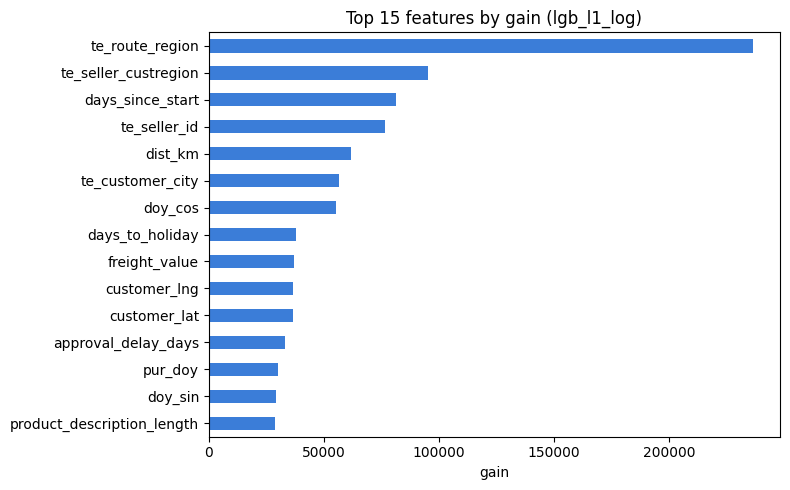

te_route_region               236267.0
te_seller_custregion           95237.0
days_since_start               81318.0
te_seller_id                   76521.0
dist_km                        61942.0
te_customer_city               56722.0
doy_cos                        55128.0
days_to_holiday                37808.0
freight_value                  37095.0
customer_lng                   36553.0
customer_lat                   36431.0
approval_delay_days            32891.0
pur_doy                        30074.0
doy_sin                        29078.0
product_description_length     28931.0
dtype: float64

In [ ]:
top = next(b for m, b in boosters if m["framework"] == "lgb")
imp = pd.Series(top.feature_importance(importance_type="gain"),
                index=top.feature_name()).sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
imp[::-1].plot.barh(color="#3b7dd8")
plt.title("Top 15 features by gain (lgb_l1_log)"); plt.xlabel("gain"); plt.tight_layout(); plt.show()
imp.round(0)

## 11. Recap

- The model in `model/` predicts delivery time for any order known at checkout, in seconds.
- It reproduces our locked **2.741** submission (correlation ~0.996).
- Geography (distance / route) and freight cost dominate; product attributes matter little.
- Use `predict_orders(your_df, train, meta, boosters)` for new orders, or `python predict.py
  your_orders.csv out.csv` from the command line.